# Finite-Sample Adequacy and Robustness of Null Distributions
## Experiment Notebook (10 Hypothesis Tests)

This notebook reproduces all simulation results and figures from the paper. It imports functions from `experiments.py` and runs three studies:

| Study | Research Question | Description |
|-------|------------------|-------------|
| **Study 1** | RQ1: Finite-sample adequacy | Sweep sample size $n \in \{5,...,500\}$ under $H_0$; measure KS distance, KL divergence, and empirical Type I error rate |
| **Study 2** | RQ2: Robustness | Fix $n=50$; violate assumptions (non-normality, variance heterogeneity, unbalanced design, small expected frequencies) |
| **Study 3** | RQ3: MC precision | Fix $n=50$; vary MC replications $N \in \{100,...,50000\}$; measure CV of Type I error across 30 independent runs |

**Tests included:** Student's t (T1), ANOVA (T2), Kruskal-Wallis (T3), Pearson's $\chi^2$ GOF (T4), Bartlett (T5), Fligner-Killeen (T6), Sign test (T7), Cochran's Q (T8), Median test (T9), Hotelling's $T^2$ (T10).

## Setup

Import dependencies and experiment functions from `experiments.py`. All test statistic generators, divergence measures (KS, KL, Type I error), and study runners are defined there.

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10, 'figure.dpi': 150, 'figure.figsize': (12, 6)})

import importlib
import experiments as exp
importlib.reload(exp)

print('Setup complete. HAS_MPL =', exp.HAS_MPL)

Setup complete. HAS_MPL = True


## Study 1: Finite-Sample Convergence (RQ1)

For each of the 10 tests, generate data under $H_0$ across sample sizes $n \in \{5, 10, 20, 30, 50, 100, 200, 500\}$ with $N = 10{,}000$ MC replications per configuration, held **identical across all tests** so that KS distances are directly comparable.

**Metrics:** KS distance (global distributional fit), KL divergence (qualitative density diagnostic), and empirical Type I error rate (tail accuracy at $\alpha = 0.05$).

**Two adequacy notions:** $n^*_\alpha$ (smallest $n$ with $|\hat\alpha-0.05|<0.01$) and $n^*_{KS}$ (smallest $n$ with $D_{KS}$ below the 95% KS critical value at $N=10{,}000$, i.e. $1.358/\sqrt{N}=0.0136$).

**Key finding:** the four exact tests (t, ANOVA, Hotelling, sign) show uniformly small KS at all $n$; Bartlett is only *asymptotically* $\chi^2$ but its correction makes it near-exact under normality; the median test has the slowest distributional convergence, and $n^*_\alpha$ can be far below $n^*_{KS}$ (e.g. Cochran's Q: 5 vs 200).

STUDY 1: Finite-sample convergence

  Student t... 

(0.2s)

  ANOVA F... 

(0.5s)

  Kruskal-Wallis... 

(3.3s)

  Chi-sq GOF... 

(0.2s)

  Bartlett... 

...

(2.5s)

  Sign test... 

(0.1s)

  Cochran Q... 

(0.6s)

  Median test... 

(1.5s)

  Hotelling T2... 

(1.6s)

--- Study 1 Results: Type I Error Rate ---
Test                     n=5    n=10    n=20    n=30    n=50   n=100   n=200   n=500
------------------------------------------------------------------------------------
Student t             0.0543  0.0540  0.0519  0.0523  0.0509  0.0487  0.0526  0.0499
ANOVA F               0.0502  0.0566  0.0515  0.0515  0.0522  0.0559  0.0503  0.0452
Kruskal-Wallis        0.0413  0.0435  0.0459  0.0519  0.0485  0.0504  0.0499  0.0472
Chi-sq GOF            0.0444  0.0456  0.0471  0.0517  0.0473  0.0492  0.0497  0.0490
Bartlett              0.0478  0.0509  0.0520  0.0501  0.0512  0.0526  0.0468  0.0488
Fligner-Killeen       0.0002  0.0284  0.0362  0.0441  0.0411  0.0476  0.0454  0.0478
Sign test             0.0000  0.0236  0.0407  0.0376  0.0318  0.0366  0.0373  0.0432
Cochran Q             0.0429  0.0449  0.0502  0.0525  0.0489  0.0511  0.0491  0.0490
Median test           0.0651  0.0357  0.0468  0.0422  0.0443  0.0576  0.0462  0.0453
Hotelling T2  

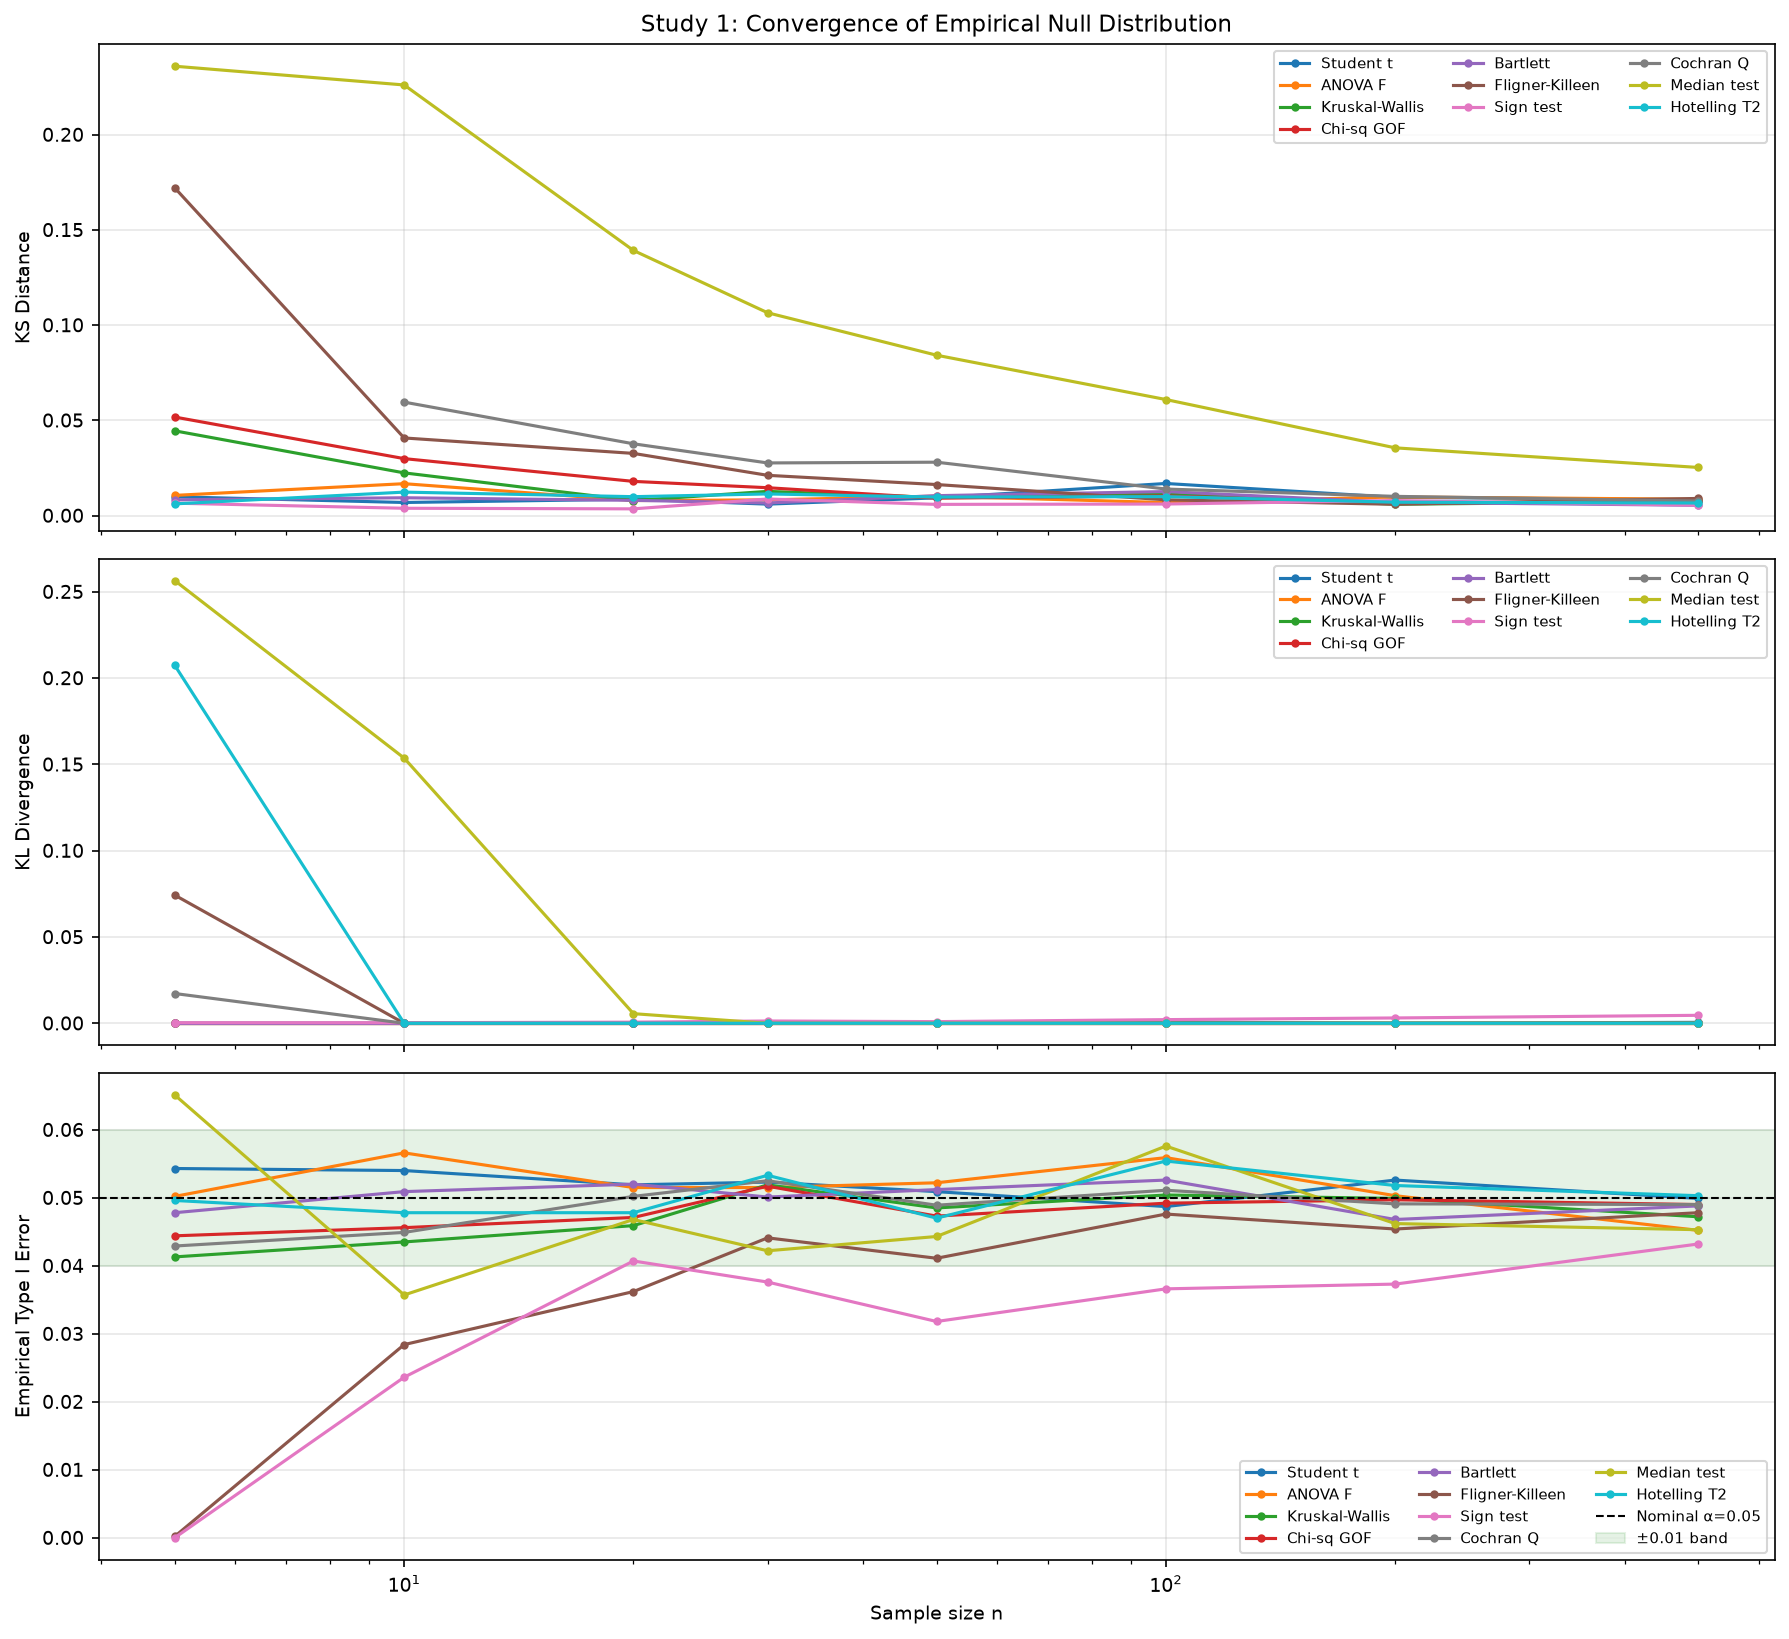

  Saved fig_study1_convergence.png
KS adequacy threshold: 0.0136
n*_alpha: {'T1_t_test': 5, 'T2_anova': 5, 'T3_kruskal_wallis': 5, 'T4_chisq_gof': 5, 'T5_bartlett': 5, 'T6_fligner_killeen': 30, 'T7_sign_test': 20, 'T8_cochran_q': 5, 'T9_median_test': 20, 'T10_hotelling': 5}
n*_KS   : {'T1_t_test': 5, 'T2_anova': 5, 'T3_kruskal_wallis': 20, 'T4_chisq_gof': 50, 'T5_bartlett': 5, 'T6_fligner_killeen': 100, 'T7_sign_test': 5, 'T8_cochran_q': 200, 'T9_median_test': '>500', 'T10_hotelling': 5}


In [2]:
s1_results, n_star_alpha = exp.run_study1(N_mc=10000)
ks_threshold = s1_results.pop('_ks_threshold')
n_star_ks = s1_results.pop('_n_star_ks')
print('KS adequacy threshold:', round(ks_threshold, 4))
print('n*_alpha:', n_star_alpha)
print('n*_KS   :', n_star_ks)

## Study 2: Robustness Under Assumption Violations (RQ2)

Fix $n = 50$ and systematically violate assumptions:

- **Non-normality (skewed):** $N(0,1)\to\text{Exp}(1)-1$ — affects T1, T2, T5, T10
- **Non-normality (heavy-tailed):** $N(0,1)\to t(5)$ — affects T1, T2, T5, T7, T10
- **Variance heterogeneity:** $\sigma_1^2=1,\ \sigma_k^2=4$ — affects T2, T3, T9
- **Unbalanced design:** group sizes in ratio 1:2:3 — affects T2, T3, T5, T6, T8, T9
- **Small expected frequencies:** T4 (min $np_j\approx2$), T8 ($p=0.05$), T9 ($n=8$/group)

All $\hat\alpha$ are reported with 95% Wilson confidence intervals (`s2_ci`).

**Key finding:** Bartlett's test inflates to $\hat\alpha = 0.429$ under skewness ($\approx$8.9$\times$ nominal); Fligner-Killeen inflates to only 0.119 ($\approx$2.9$\times$). The sign test is run on three different parents (normal/Exp/$t_5$) yet stays $\approx$0.03, illustrating exact distribution-freeness.


STUDY 2: Robustness under assumption violations

  Student t... 

(0.0s)

  ANOVA F... 

(0.2s)

  Kruskal-Wallis... 

(1.6s)

  Chi-sq GOF... 

(0.0s)

  Bartlett... 

...

(2.4s)

  Sign test... 

(0.0s)

  Cochran Q... 

(0.1s)

  Median test... 

(0.9s)

  Hotelling T2... 

(0.5s)

--- Study 2 Results: Empirical Type I Error (α=0.05) ---
Test                    baseline      skewed  heavy_tail  hetero_var  unbalanced  small_freq
--------------------------------------------------------------------------------------------
Student t                 0.0524      0.0663      0.0455           —           —           —
ANOVA F                   0.0461      0.0434      0.0477      0.0610      0.0488           —
Kruskal-Wallis            0.0465      0.0513      0.0491      0.0641      0.0515           —
Chi-sq GOF                0.0494           —           —           —           —      0.0512
Bartlett                  0.0479     0.4288*     0.2760*           —      0.0513           —
Fligner-Killeen           0.0410     0.1191*      0.0425           —      0.0448           —
Sign test                 0.0352      0.0307      0.0312           —           —           —
Cochran Q                 0.0496           —           —           —      0.0500      0.0406
Media

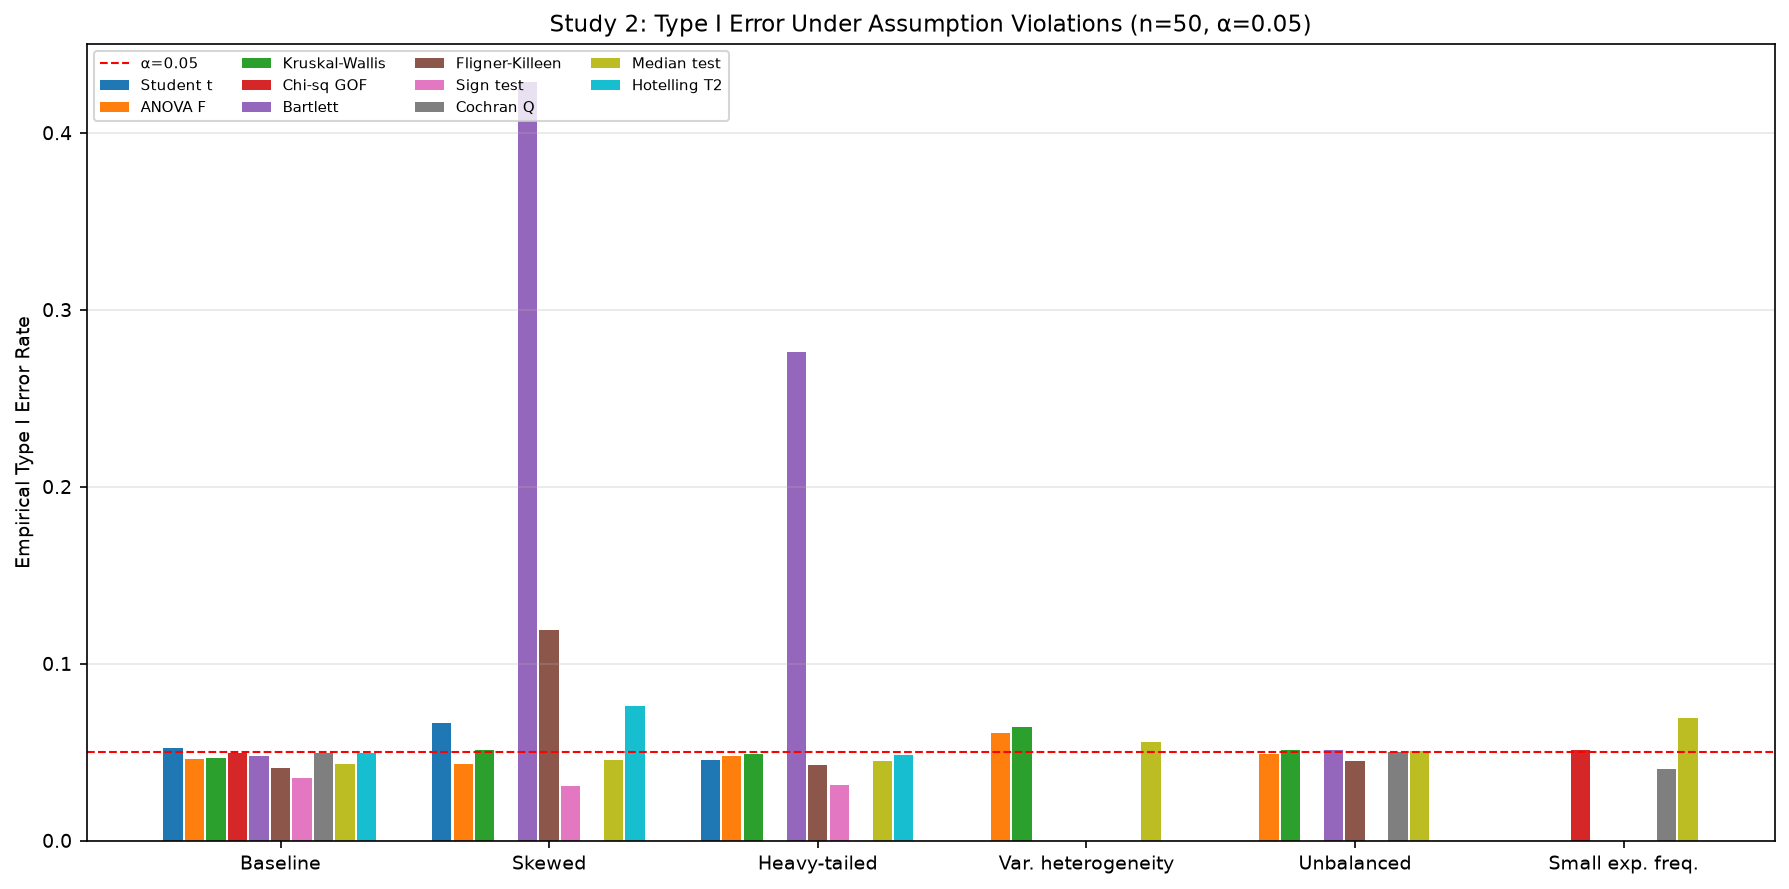

  Saved fig_study2_robustness.png


In [3]:
s2_results, s2_ci = exp.run_study2(N_mc=10000, n_fixed=50)

## Study 3: MC Precision Requirements (RQ3)

Fix $n = 50$ and vary MC replications $N \in \{100, 500, 1000, 1500, 2000, 3000, 5000, 10000, 50000\}$. For each $N$, repeat 30 independent runs and compute the coefficient of variation (CV) of $\hat{\alpha}$.

**Criterion:** $N^*$ = smallest $N$ for which $\text{CV}(\hat{\alpha}) < 0.10$.

**Key finding:** ANOVA is most efficient ($N^* = 1{,}500$); most tests reach $N^* = 2{,}000$; discrete / rank-based statistics (sign, Cochran, Fligner-Killeen) need $N^* = 3{,}000$. $N = 10{,}000$ keeps CV below 5.5% for all tests.


STUDY 3: MC precision requirements

  Student t... 

(1.3s)

  ANOVA F... 

(3.9s)

  Kruskal-Wallis... 

(21.9s)

  Chi-sq GOF... 

(0.8s)

  Bartlett... 

...

(22.7s)

  Sign test... 

(1.2s)

  Cochran Q... 

(5.0s)

  Median test... 

(10.2s)

  Hotelling T2... 

(10.5s)

--- Study 3 Results: CV of Type I Error ---
Test                N=100     N=500    N=1000    N=1500    N=2000    N=3000    N=5000   N=10000   N=50000
---------------------------------------------------------------------------------------------------------
Student t          0.4204    0.2149    0.1416    0.1101    0.0780    0.0865    0.0668    0.0419    0.0182
ANOVA F            0.4166    0.1901    0.1373    0.0757    0.1123    0.0835    0.0671    0.0375    0.0217
Kruskal-Wallis     0.3835    0.1783    0.1721    0.1365    0.0855    0.0961    0.0449    0.0449
Chi-sq GOF         0.3547    0.2590    0.1101    0.1287    0.0793    0.0725    0.0611    0.0437    0.0206
Bartlett           0.3691    0.1567    0.1441    0.1301    0.0986    0.0672    0.0574    0.0444    0.0195
Fligner-Killeen    0.5989    0.2277    0.1412    0.1022    0.1061    0.0552    0.0628    0.0476    0.0239
Sign test          0.4244    0.3252    0.1346    0.1482    0.1161    0.0877    0.0882    0.0493    0.0243
Coc

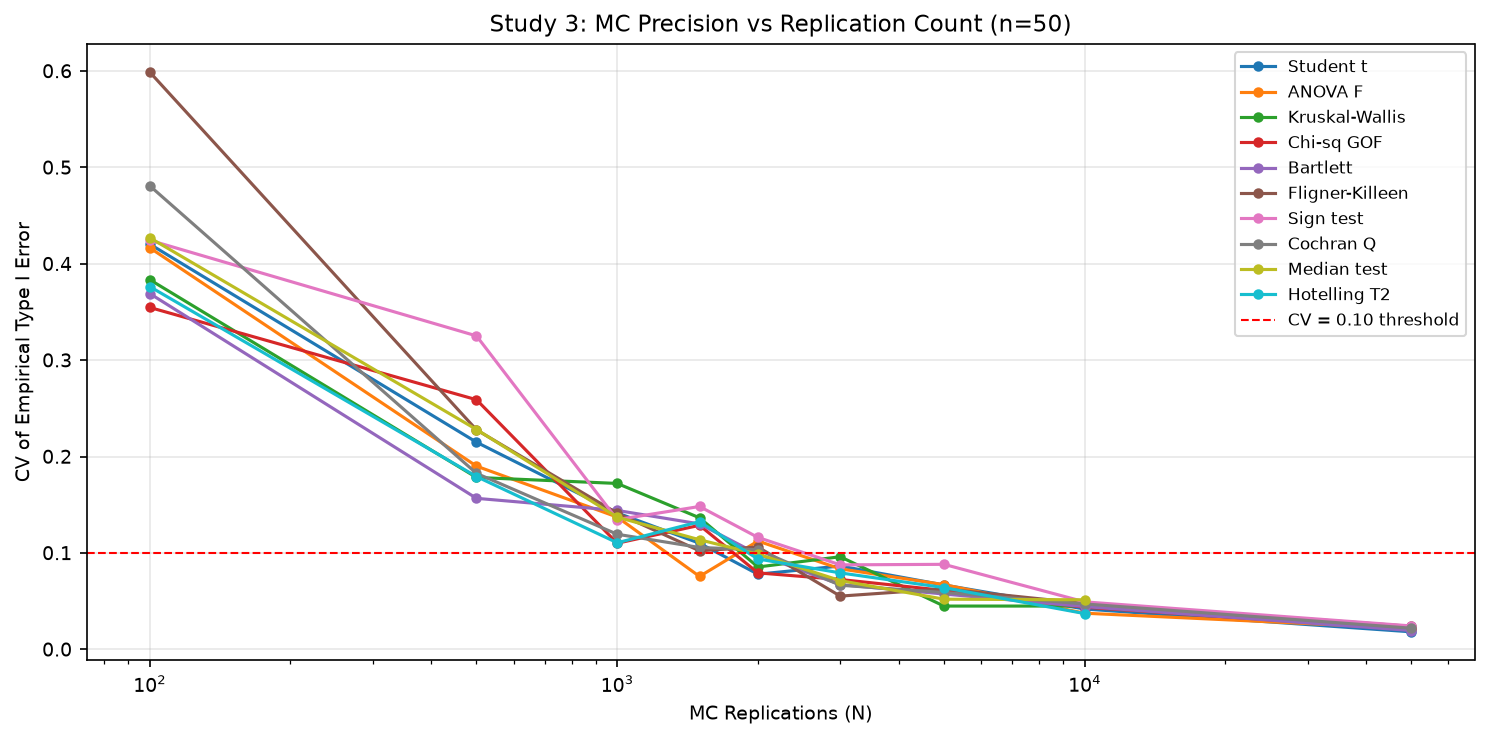

  Saved fig_study3_precision.png


In [4]:
s3_results, n_star_mc = exp.run_study3(n_fixed=50, n_repeats=30)

## Save Results

Export all results to `experiment_results.json` for use in the paper.

In [5]:
import json
import numpy as np

# Auto-generate all markdown tables (Tables 3/4/5) so they match the saved results exactly
exp.generate_tables(s1_results, n_star_alpha, n_star_ks, ks_threshold,
                    s2_results, s2_ci, s3_results, n_star_mc, 'generated_tables.md')

def _clean(vv):
    return [float(x) if not (isinstance(x, float) and np.isnan(x)) else None for x in vv]

all_results = {
    'study1': {tid: {kk: (_clean(vv) if isinstance(vv, list) else vv)
                     for kk, vv in s1_results[tid].items()} for tid in s1_results},
    'study1_nstar_alpha': {k: str(v) for k, v in n_star_alpha.items()},
    'study1_nstar_ks': {k: str(v) for k, v in n_star_ks.items()},
    'study1_ks_threshold': ks_threshold,
    'study2': {tid: {kk: (float(vv) if not (isinstance(vv, float) and np.isnan(vv)) else None)
                     for kk, vv in s2_results[tid].items()} for tid in s2_results},
    'study2_ci': s2_ci,
    'study3': {k: v for k, v in s3_results.items()},
    'study3_nstar_mc': {k: str(v) for k, v in n_star_mc.items()},
}
with open('experiment_results.json', 'w') as f:
    json.dump(all_results, f, indent=2, default=str)
print('Saved experiment_results.json and generated_tables.md')

  Saved generated_tables.md
Saved experiment_results.json and generated_tables.md


## Generated Tables and Figures

The tables below (Tables 3/4/5 in the paper) and the three figures are produced directly from the runs above, so the notebook outputs match the committed results file exactly.

# Auto-generated result tables

Generated by experiments.py. Study 1/2 use N=10,000 MC replications (uniform across all tests). Study 1 KS adequacy threshold = 95% KS critical value at N=10,000 = 0.0136. CIs are 95% Wilson score intervals.


## Table 3: Minimum adequate sample size

| Test | $n^*_\alpha$ ($|\hat\alpha-0.05|<0.01$) | $n^*_{KS}$ ($D_{KS}<0.014$) |
| --- | --- | --- |
| T1: Student's t | 5 | 5 |
| T2: ANOVA F | 5 | 5 |
| T3: Kruskal-Wallis | 5 | 20 |
| T4: Pearson's $\chi^2$ GOF | 5 | 50 |
| T5: Bartlett's | 5 | 5 |
| T6: Fligner-Killeen | 30 | 100 |
| T7: Sign test | 20 | 5 |
| T8: Cochran's Q | 5 | 200 |
| T9: Median test | 20 | >500 |
| T10: Hotelling's $T^2$ | 5 | 5 |

## Table 4: Empirical Type I error under assumption violations (α=0.05, n=50, N=10,000)

| Test | Baseline | Skewed | Heavy-tailed | Var. het. | Unbalanced | Small exp. freq. |
| --- | --- | --- | --- | --- | --- | --- |
| T1: Student's t | 0.052 | 0.066 | 0.045 | — | — | — |
| T2: ANOVA F | 0.046 | 0.043 | 0.048 | 0.061 | 0.049 | — |
| T3: Kruskal-Wallis | 0.046 | 0.051 | 0.049 | 0.064 | 0.051 | — |
| T4: Pearson's $\chi^2$ GOF | 0.049 | — | — | — | — | 0.051 |
| T5: Bartlett's | 0.048 | 0.429 | 0.276 | — | 0.051 | — |
| T6: Fligner-Killeen | 0.041 | 0.119 | 0.043 | — | 0.045 | — |
| T7: Sign test | 0.035 | 0.031 | 0.031 | — | — | — |
| T8: Cochran's Q | 0.050 | — | — | — | 0.050 | 0.041 |
| T9: Median test | 0.043 | 0.046 | 0.045 | 0.056 | 0.051 | 0.069 |
| T10: Hotelling's $T^2$ | 0.050 | 0.076 | 0.048 | — | — | — |

### Table 4 with 95% Wilson CIs

| Test | Baseline | Skewed | Heavy-tailed | Var. het. | Unbalanced | Small exp. freq. |
| --- | --- | --- | --- | --- | --- | --- |
| T1: Student's t | 0.052 [0.048, 0.057] | 0.066 [0.062, 0.071] | 0.045 [0.042, 0.050] | — | — | — |
| T2: ANOVA F | 0.046 [0.042, 0.050] | 0.043 [0.040, 0.048] | 0.048 [0.044, 0.052] | 0.061 [0.056, 0.066] | 0.049 [0.045, 0.053] | — |
| T3: Kruskal-Wallis | 0.046 [0.043, 0.051] | 0.051 [0.047, 0.056] | 0.049 [0.045, 0.054] | 0.064 [0.059, 0.069] | 0.051 [0.047, 0.056] | — |
| T4: Pearson's $\chi^2$ GOF | 0.049 [0.045, 0.054] | — | — | — | — | 0.051 [0.047, 0.056] |
| T5: Bartlett's | 0.048 [0.044, 0.052] | 0.429 [0.419, 0.439] | 0.276 [0.267, 0.285] | — | 0.051 [0.047, 0.056] | — |
| T6: Fligner-Killeen | 0.041 [0.037, 0.045] | 0.119 [0.113, 0.126] | 0.043 [0.039, 0.047] | — | 0.045 [0.041, 0.049] | — |
| T7: Sign test | 0.035 [0.032, 0.039] | 0.031 [0.027, 0.034] | 0.031 [0.028, 0.035] | — | — | — |
| T8: Cochran's Q | 0.050 [0.046, 0.054] | — | — | — | 0.050 [0.046, 0.054] | 0.041 [0.037, 0.045] |
| T9: Median test | 0.043 [0.040, 0.048] | 0.046 [0.042, 0.050] | 0.045 [0.041, 0.050] | 0.056 [0.052, 0.061] | 0.051 [0.047, 0.055] | 0.069 [0.064, 0.074] |
| T10: Hotelling's $T^2$ | 0.050 [0.046, 0.054] | 0.076 [0.071, 0.081] | 0.048 [0.044, 0.053] | — | — | — |

## Table 5: Minimum MC replications $N^*$ for CV < 0.10

| Test | $N^*$ | CV at N=1,000 | CV at N=10,000 |
| --- | --- | --- | --- |
| T1: Student's t | 2000 | 0.142 | 0.042 |
| T2: ANOVA F | 1500 | 0.137 | 0.038 |
| T3: Kruskal-Wallis | 2000 | 0.172 | 0.045 |
| T4: Pearson's $\chi^2$ GOF | 2000 | 0.110 | 0.044 |
| T5: Bartlett's | 2000 | 0.144 | 0.044 |
| T6: Fligner-Killeen | 3000 | 0.141 | 0.048 |
| T7: Sign test | 3000 | 0.135 | 0.049 |
| T8: Cochran's Q | 3000 | 0.119 | 0.047 |
| T9: Median test | 2000 | 0.137 | 0.051 |
| T10: Hotelling's $T^2$ | 2000 | 0.111 | 0.037 |


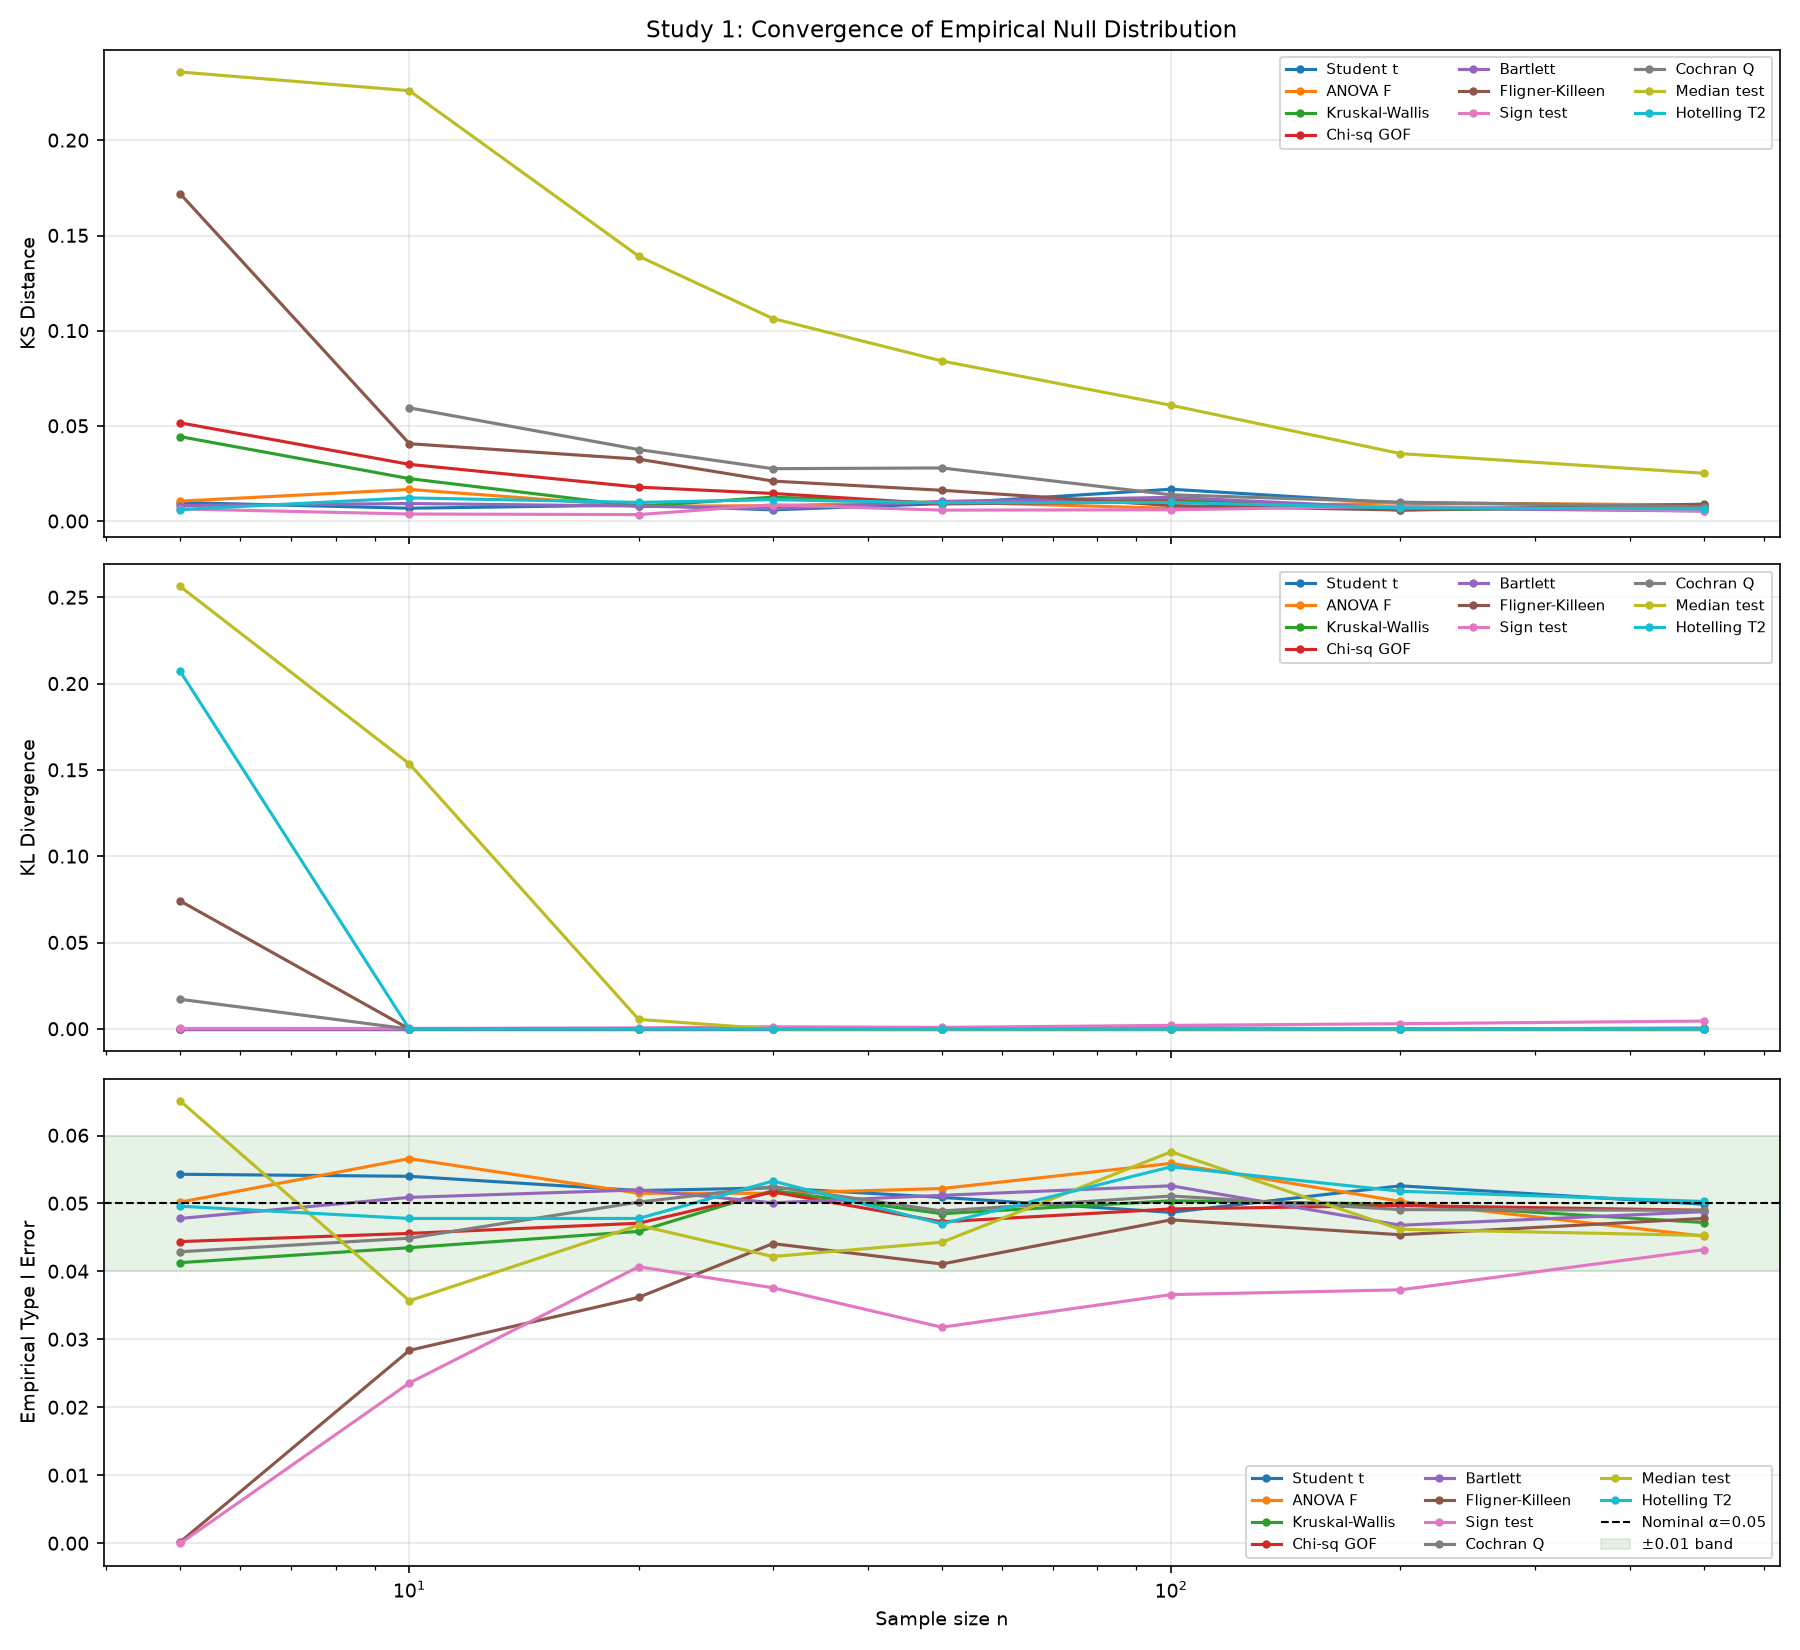

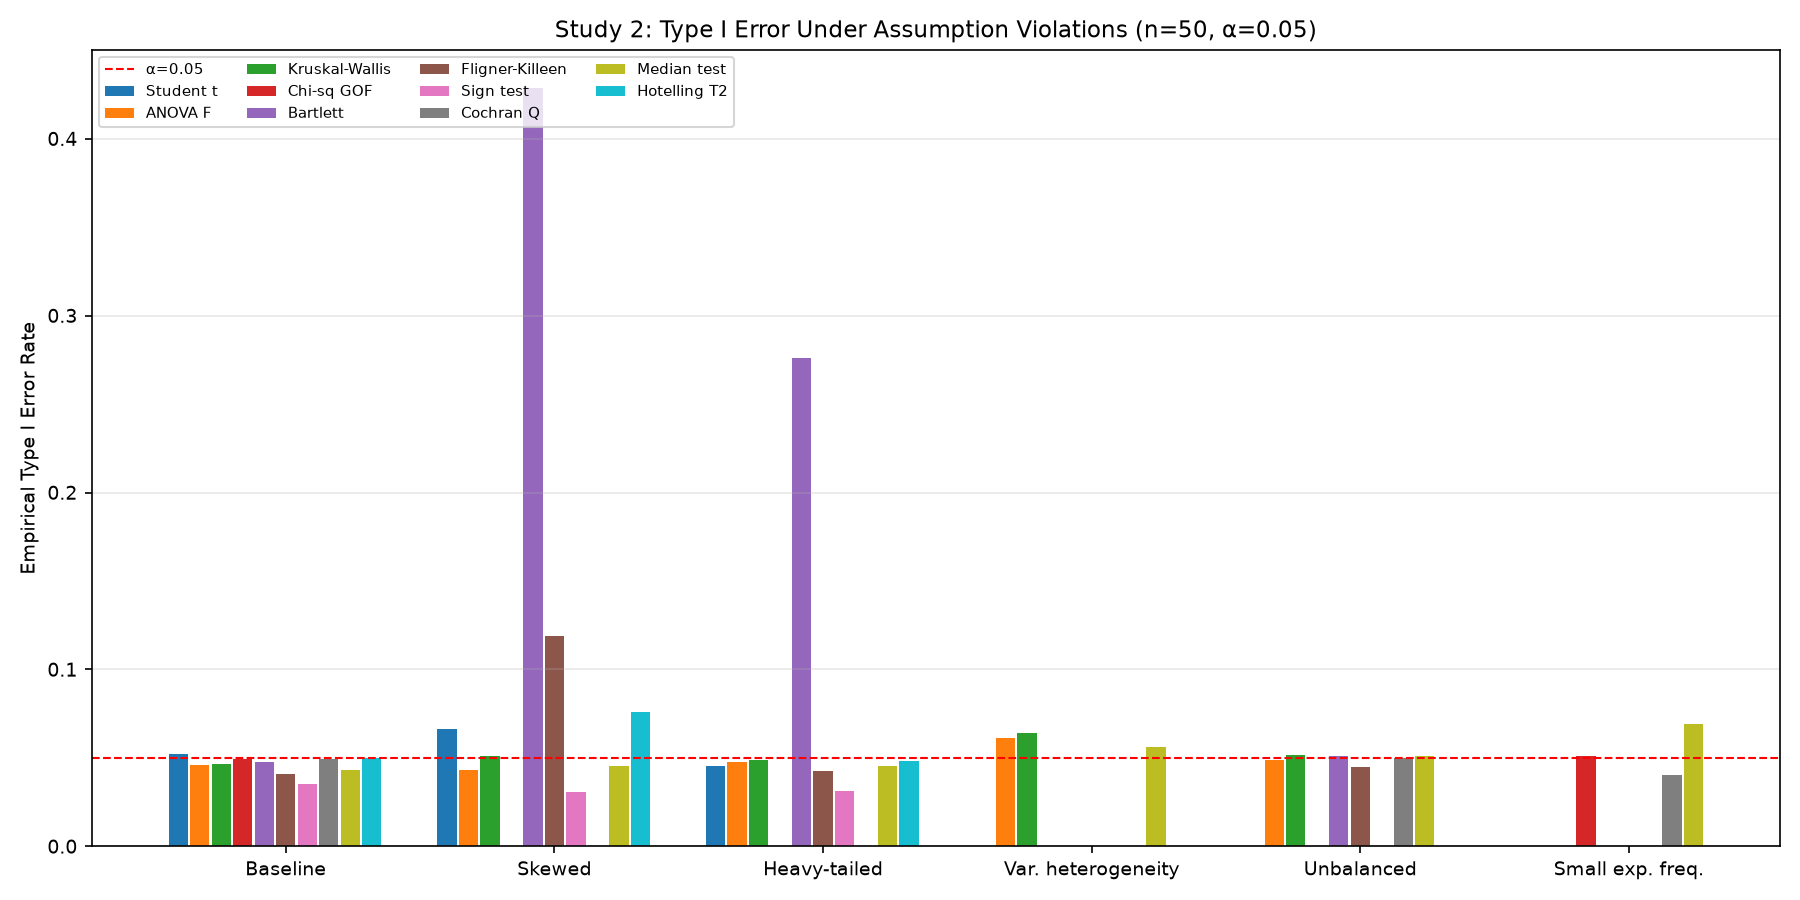

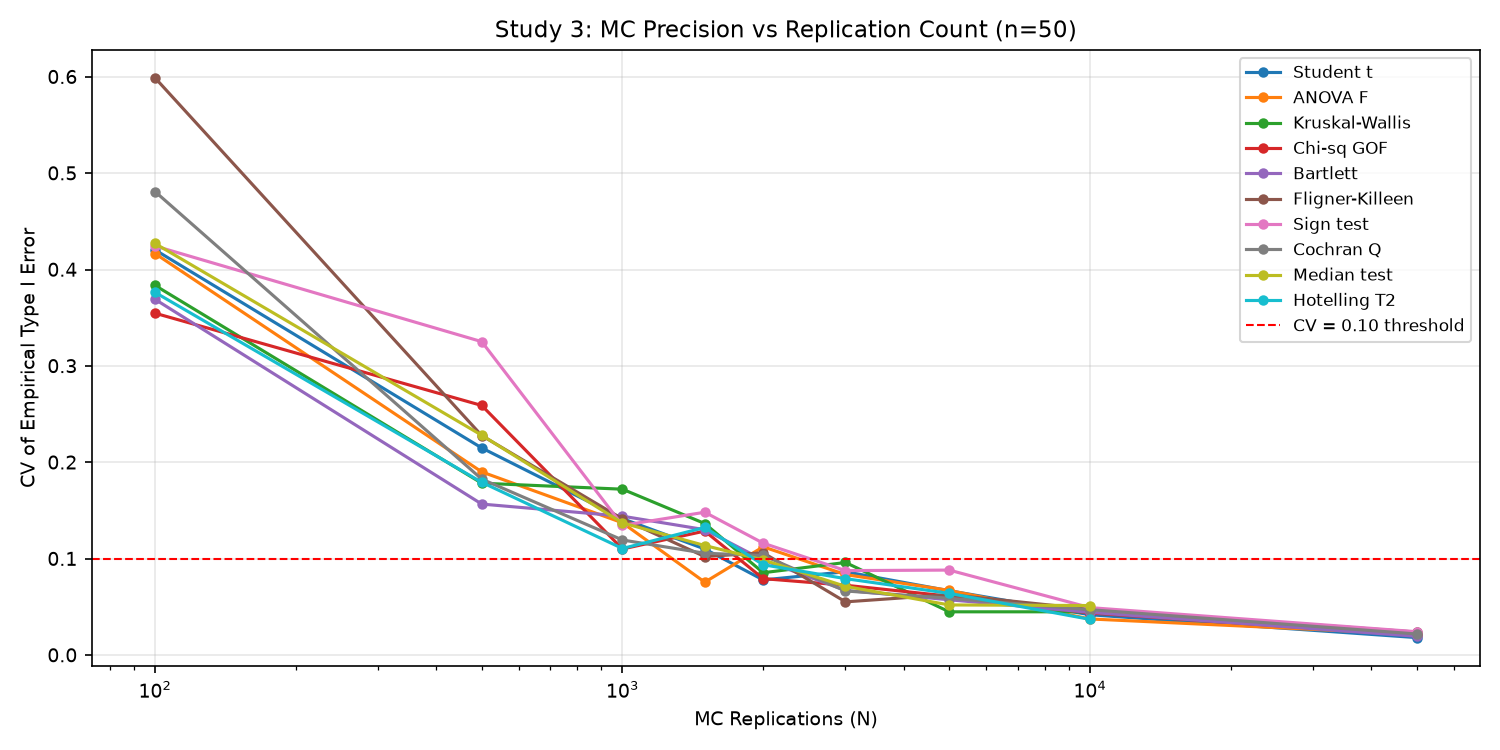

In [6]:
from IPython.display import Markdown, Image, display

display(Markdown(open('generated_tables.md').read()))
for fn in ['fig_study1_convergence.png', 'fig_study2_robustness.png', 'fig_study3_precision.png']:
    display(Image(filename=fn))